# New York Mets Batting Stats (1962-2023) ⚾️

In this notebook, we will conduct exploratory data analysis (EDA) on the New York Mets hitting stats from 1962-2023. We will determine who were the best offensive players in New York Mets history. We seek to understand the data's patterns, relationships, and potential trends, while ensuring its quality to support accurate and meaningful insights.

# Dataset Description


New York Mets dataset 🏟

This dataset provides detailed insights into the batting stats of the New York Mets from 1962-2023 . It holds information focusing on different offensive stats such as

*Collumn Descriptions*



*  **Name:** The name of the player.
*   **Year:** The year the batting statistics were recorded.
* **At_Bats:** The number of times a player batted, excluding walks, sacrifices, and hit-by-pitches.
*   **Runs:** The number of times a player scored a run.
*  **Hits:** The number of times a player safely reached base after hitting the ball.
*   **Doubles:** The number of hits where a player advanced to second base.
*   **Home_Runs:** The number of hits where a player scored a run by hitting the ball out of the playing field.
*   **On_Base_Percentage:** A measure of how often a batter reaches base.

*  ** Slugging_Percentage:** A measure of the total number of bases a player gains per official at-bat.
*  **On_Base_Plus_Slugging_Percentage:** A measure of a player's offensive production, calculated as the sum of On-Base Percentage and Slugging Percentage

















# Data Cleaning and Wrangling

lets load our data and preview a few rows

In [ ]:
#libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [ ]:
#loading our dataset
newyorkmetshitting_data = pd.read_csv('https://raw.githubusercontent.com/floresadonis333/NewYorkMetsBatting_Data-/refs/heads/main/NYM_batting.csv')
newyorkmetshitting_data.shape

(2728, 31)

As we can see we have way too many collumns, so I am going to drop most of them and choose the ones I feel support what im looking for.

In [ ]:
columns_to_keep= ['Name','Year','At_Bats','Runs','Hits','Doubles','Home_Runs','On_Base_Percentage', 'Slugging_Percentage', 'On_Base_Plus_Slugging_Percentage']
newyorkmetshitting_data = newyorkmetshitting_data[columns_to_keep]
newyorkmetshitting_data.shape

(2728, 10)

In [ ]:
newyorkmetshitting_data.head()

,Name,Year,At_Bats,Runs,Hits,Doubles,Home_Runs,On_Base_Percentage,Slugging_Percentage,On_Base_Plus_Slugging_Percentage
0,Francisco Álvarez,2023,382,51,80,12,25,0.284,0.437,0.721
1,Pete Alonso,2023,568,92,123,21,46,0.318,0.504,0.821
2,Jeff McNeil,2023,585,75,158,25,10,0.333,0.378,0.711
3,Francisco Lindor,2023,602,108,153,33,31,0.336,0.470,0.806
4,Brett Baty,2023,353,41,75,12,9,0.275,0.323,0.598


In [ ]:
newyorkmetshitting_data.tail()

,Name,Year,At_Bats,Runs,Hits,Doubles,Home_Runs,On_Base_Percentage,Slugging_Percentage,On_Base_Plus_Slugging_Percentage
2723,Herb Moford,1962,4,0,1,0,0,0.25,0.25,0.5
2724,Larry Foss,1962,1,0,0,0,0,0.00,0.00,0.0
2725,Dave Hillman,1962,1,0,0,0,0,0.00,0.00,0.0
2726,Bob Miller,1962,1,0,0,0,0,0.00,0.00,0.0
2727,Clem Labine,1962,0,0,0,0,0,0.00,0.00,0.0


In [ ]:
newyorkmetshitting_data.sample(12)

,Name,Year,At_Bats,Runs,Hits,Doubles,Home_Runs,On_Base_Percentage,Slugging_Percentage,On_Base_Plus_Slugging_Percentage
2078,Ed Kranepool,1978,81,7,17,2,3,0.280,0.346,0.625
1970,Pete Falcone,1981,22,1,4,0,1,0.182,0.318,0.500
364,Jacob deGrom,2017,71,6,15,1,1,0.233,0.268,0.500
1874,Mookie Wilson,1983,638,91,176,25,7,0.300,0.367,0.666
490,Rubén Tejada,2014,355,30,84,11,5,0.342,0.310,0.652
2484,Joe Moock,1967,40,2,9,2,0,0.225,0.275,0.500
1963,Ron Hodges,1981,43,5,13,2,1,0.375,0.419,0.794
555,Wilfredo Tovar,2013,15,1,3,0,0,0.294,0.200,0.494
1182,Bubba Trammell,2000,56,9,13,2,3,0.323,0.429,0.752
2689,Jim Hickman,1962,392,54,96,18,13,0.328,0.401,0.729


I dont see any NaN values as of right now but I am still going to run the code to check for them just to make sure there isnt any NaN values in the data.

In [ ]:
# Check for NaN values in each column
nan_counts = newyorkmetshitting_data.isna().sum()

# Print the results
print(nan_counts)

Name                                0
Year                                0
At_Bats                             0
Runs                                0
Hits                                0
Doubles                             0
Home_Runs                           0
On_Base_Percentage                  0
Slugging_Percentage                 0
On_Base_Plus_Slugging_Percentage    0
dtype: int64


Great, as we can see we have no NaN values throughtout the data so now I am going to check for duplicates.

In [ ]:
newyorkmetshitting_data.duplicated().sum()

np.int64(0)

Now that I have checked for errors I am going to filter my current data to hitters who have completed at least 250 at bats to qualify as one of the best players.

In [ ]:
newyorkmetshitting_data_filter = newyorkmetshitting_data[newyorkmetshitting_data['At_Bats'] >= 250]
newyorkmetshitting_data_filter.head()

,Name,Year,At_Bats,Runs,Hits,Doubles,Home_Runs,On_Base_Percentage,Slugging_Percentage,On_Base_Plus_Slugging_Percentage
0,Francisco Álvarez,2023,382,51,80,12,25,0.284,0.437,0.721
1,Pete Alonso,2023,568,92,123,21,46,0.318,0.504,0.821
2,Jeff McNeil,2023,585,75,158,25,10,0.333,0.378,0.711
3,Francisco Lindor,2023,602,108,153,33,31,0.336,0.470,0.806
4,Brett Baty,2023,353,41,75,12,9,0.275,0.323,0.598


In [ ]:
newyorkmetshitting_data_filter.describe()

,Year,At_Bats,Runs,Hits,Doubles,Home_Runs,On_Base_Percentage,Slugging_Percentage,On_Base_Plus_Slugging_Percentage
count,556.000000,556.000000,556.000000,556.000000,556.000000,556.000000,556.000000,556.000000,556.000000
mean,1991.694245,417.163669,54.525180,110.494604,19.762590,11.820144,0.331045,0.402464,0.733491
std,17.700818,109.418217,22.536003,34.801392,8.478766,9.684948,0.036387,0.074076,0.100639
min,1962.000000,250.000000,14.000000,46.000000,3.000000,0.000000,0.220000,0.204000,0.438000
25%,1976.000000,325.000000,37.000000,82.000000,13.000000,4.000000,0.306750,0.346000,0.666000
50%,1991.000000,403.000000,49.000000,106.000000,19.000000,10.000000,0.331000,0.403000,0.731000
75%,2007.000000,509.250000,69.000000,136.000000,25.000000,16.000000,0.353000,0.449000,0.799250
max,2023.000000,696.000000,127.000000,227.000000,44.000000,53.000000,0.447000,0.614000,1.024000


As

In [ ]:
newyorkmetshitting_data_filter.shape


(556, 10)

In [ ]:
newyorkmetshitting_data_filter.head()

,Name,Year,At_Bats,Runs,Hits,Doubles,Home_Runs,On_Base_Percentage,Slugging_Percentage,On_Base_Plus_Slugging_Percentage
0,Francisco Álvarez,2023,382,51,80,12,25,0.284,0.437,0.721
1,Pete Alonso,2023,568,92,123,21,46,0.318,0.504,0.821
2,Jeff McNeil,2023,585,75,158,25,10,0.333,0.378,0.711
3,Francisco Lindor,2023,602,108,153,33,31,0.336,0.470,0.806
4,Brett Baty,2023,353,41,75,12,9,0.275,0.323,0.598

































































































# Measure of Central Tendency

**Package Needed**



*   NumPy: A fundamental Python package for scientific computing, providing efficient arrays and mathematical operations.

Now we'll be using central tendency (mean,median or mode) to answer some questions ive come up with.

**1.) What is the average number of At-Bats per player season in your filtered dataset?**

In [ ]:
# Calculate the average number of At-Bats
average_at_bats = newyorkmetshitting_data_filter['At_Bats'].mean()

# Print the result
print(f"The average number of At-Bats per player season in the filtered dataset is: {average_at_bats:.2f}")

The average number of At-Bats per player season in the filtered dataset is: 417.16


As we can see average number of At-Bats in this data is 417.16.

**2.) What is the average On-Base Plus slugging Percentage (OPS) for players who had at least 150 at-bats in a season?**

In [ ]:
# Calculate the average On-Base Plus Slugging Percentage (OPS)
average_ops = newyorkmetshitting_data_filter['On_Base_Plus_Slugging_Percentage'].mean()

# Print the result
print(f"The average On-Base Plus Slugging Percentage (OPS) for players with at least 250 at-bats is: {average_ops:.3f}")

The average On-Base Plus Slugging Percentage (OPS) for players with at least 250 at-bats is: 0.733


This indicates that the OPS for Mets players in this data is .733 which is currently above league average in 2025.

**3.) What is the average On-Base Percentage for Mets hitters in this data?**

In [ ]:
# Calculate the average On-Base Percentage (OBP)
average_obp = newyorkmetshitting_data_filter['On_Base_Percentage'].mean()

# Print the result
print(f"The average On-Base Percentage (OBP) for players in the filtered dataset is: {average_obp:.3f}")

The average On-Base Percentage (OBP) for players in the filtered dataset is: 0.331


The average OBP for this data of mets hitters is .331

In [ ]:
# Calculate the median Slugging Percentage
median_slg = newyorkmetshitting_data_filter['Slugging_Percentage'].median()

# Print the result
print(f"The median Slugging Percentage for players with at least 250 at-bats is: {median_slg:.3f}")

The median Slugging Percentage for players with at least 250 at-bats is: 0.403


As we can see the median Slugging Percentage for players with at least 250 at-bats is. .403 which is currently slightly higher than league average in 2025.

In [ ]:
# Calculate the median Runs scored
median_runs = newyorkmetshitting_data_filter['Runs'].median()

# Print the result
print(f"The median Runs scored for players in the filtered dataset is: {median_runs:.0f}")

The median Runs scored for players in the filtered dataset is: 49


The Median runs scored for players in this data is 49.

Now that we have answered some Measures of Central Tendency questions lets look into some different Visulaizations

# Pairplot

Visualations

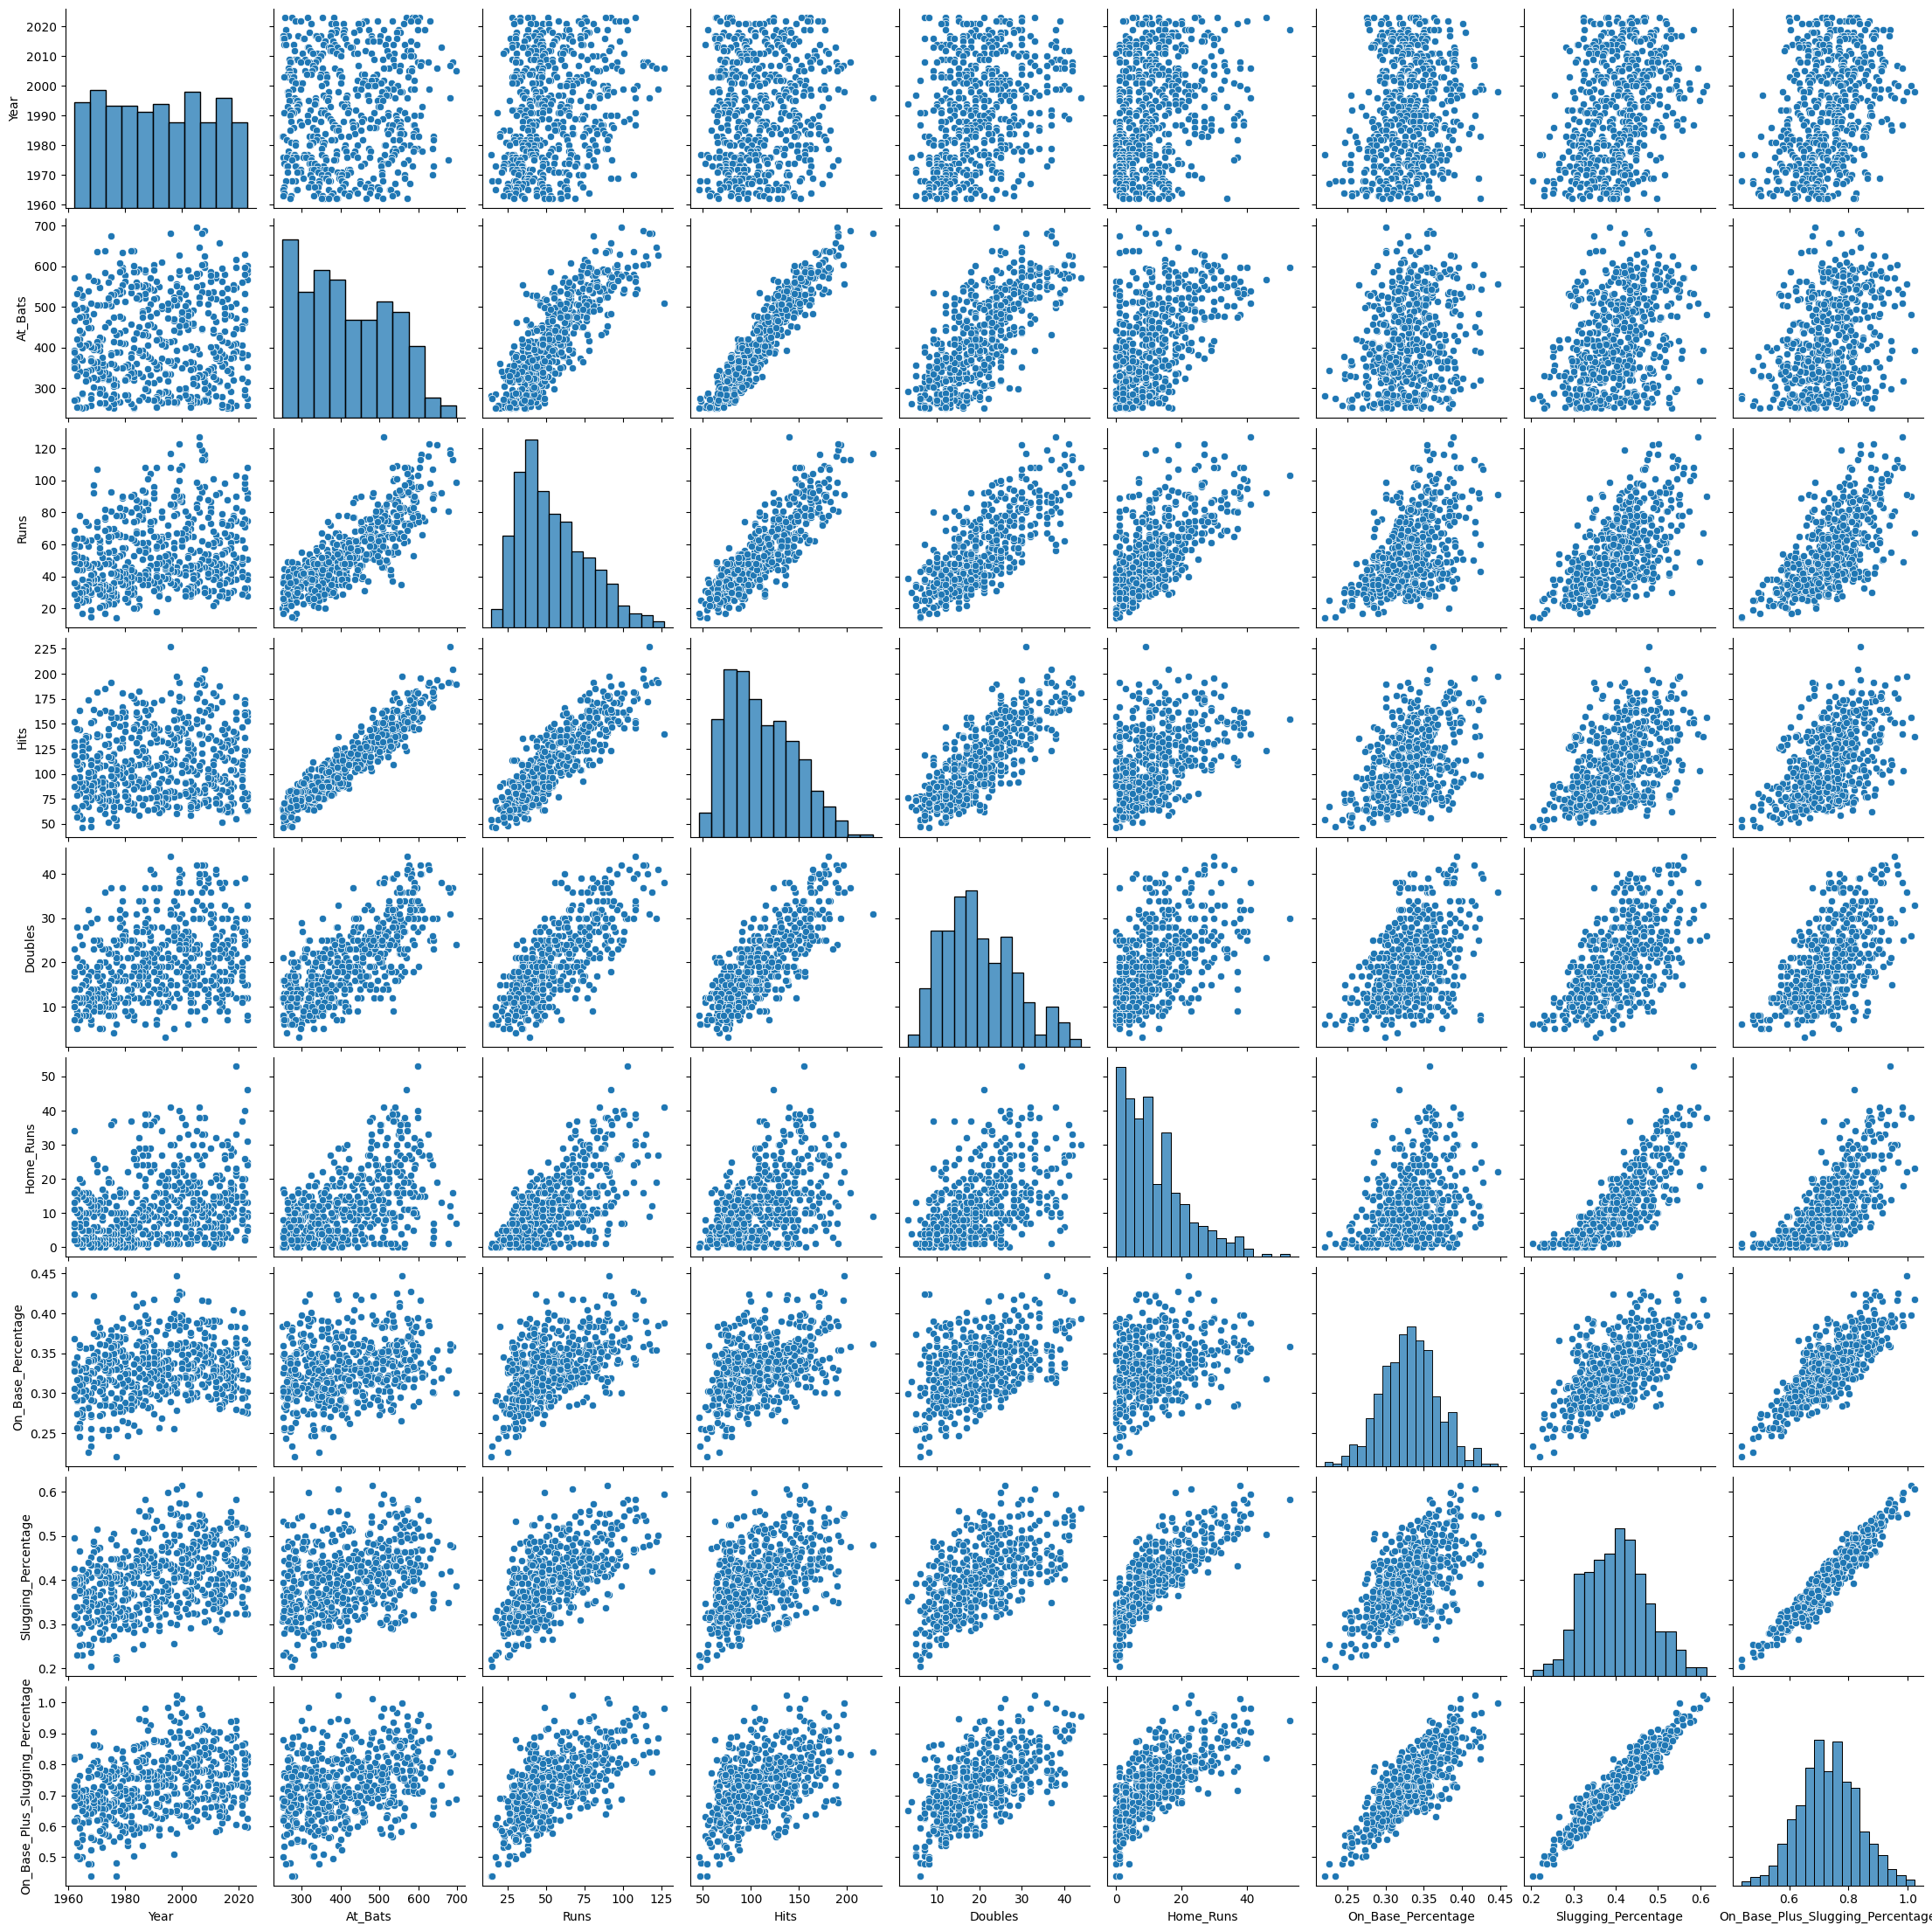

In [ ]:
sns.pairplot(newyorkmetshitting_data_filter)
plt.show()

***Specific Relationships/Patterns:***

**Positive Correlation:**

Hits vs. At_Bats: As you'd expect, there's a strong positive correlation between the number of At-Bats and the number of Hits. This suggests more opportunities to hit generally lead to more hits.

Home_Runs vs. Slugging_Percentage: Home runs are a major component of slugging percentage, so the players with higher home run numbers usually have the higher Slugging percentage.

**Negative Correlation:**

Players who have low OBP, and low slugging percentage will have On_Base_Plus_Slugging numbers which in my opinion is the most important offenseive stat.

# Additional Visualization

***Histogram***

What is the distribution of "On_Base_Plus_Slugging_Percentage" for players in your filtered dataset? Does the distribution suggest that most players have OPS values around the average, or are there players with significantly higher or lower OPS values?

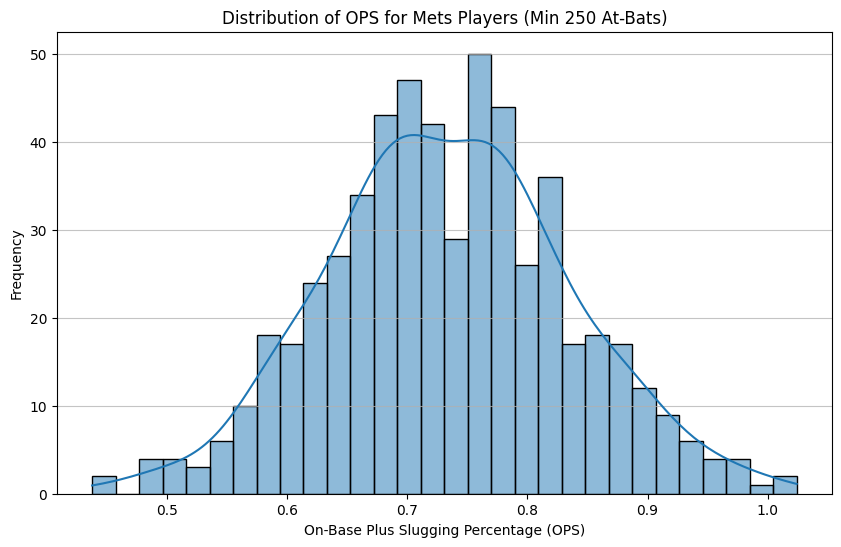

In [ ]:
# Plot a histogram of On-Base Plus Slugging Percentage (OPS)
plt.figure(figsize=(10, 6))
sns.histplot(data=newyorkmetshitting_data_filter, x='On_Base_Plus_Slugging_Percentage', bins=30, kde=True)
plt.title('Distribution of OPS for Mets Players (Min 250 At-Bats)')
plt.xlabel('On-Base Plus Slugging Percentage (OPS)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

Based off this Histogram we can see the frequency of different On-Base Plus Slugging Percentage values on this data

The histgram is right skewed which means its postively skewed




# Bar Plot of Average Offensive Stats for Top 10 Players (by OPS)

/tmp/ipython-input-3053583351.py:14: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=melted_data,


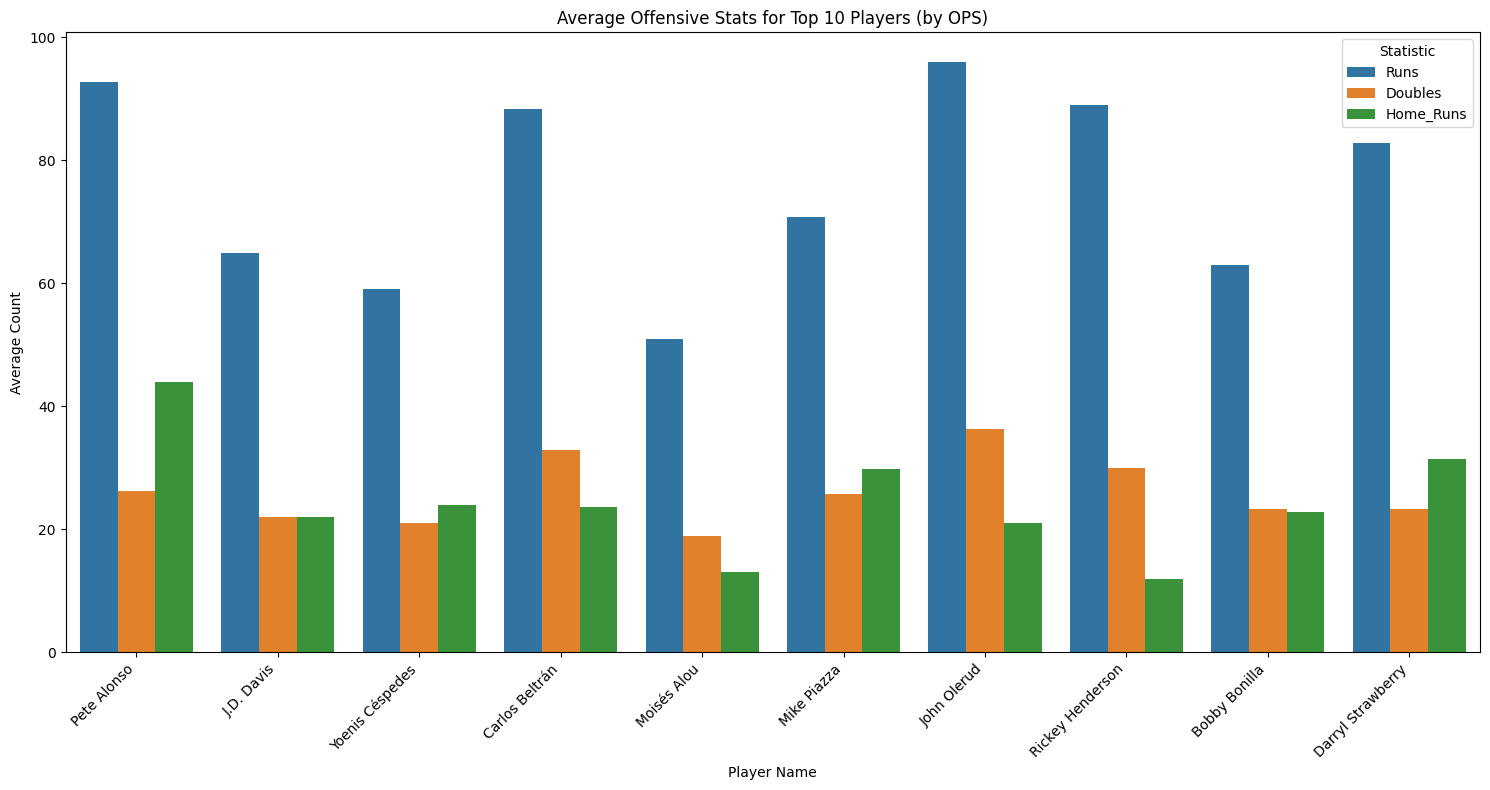

In [ ]:
# Get the top 10 players by average OPS
top_players = newyorkmetshitting_data_filter.groupby('Name')['On_Base_Plus_Slugging_Percentage'].mean().nlargest(10).index

# Filter the data for these top players
top_players_data = newyorkmetshitting_data_filter[newyorkmetshitting_data_filter['Name'].isin(top_players)]

# Melt the data to long format for plotting
melted_data = top_players_data.melt(id_vars=['Name', 'Year'],
                                    value_vars=['Runs', 'Doubles', 'Home_Runs'],
                                    var_name='Stat',
                                    value_name='Value')

plt.figure(figsize=(15, 8))
sns.barplot(data=melted_data,
            x='Name',
            y='Value',
            hue='Stat',  # Use hue to separate bars by statistic
            ci=None)     # Turn off confidence intervals for cleaner look

plt.title('Average Offensive Stats for Top 10 Players (by OPS)')
plt.xlabel('Player Name')
plt.ylabel('Average Count')
plt.xticks(rotation=45, ha='right') # Rotate labels for readability
plt.legend(title='Statistic')
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

As we can see this visualization effectively shows the top 10 offensive players based on their OPS and further breaks down their performance by showing their average Runs, Doubles, and Home Runs.

# Probability Questions

**Question 1** (Involving AND logic)

What is the probability of a player season having at least 75 runs AND at least 20 home runs?

In [ ]:
runs_and_hrs = newyorkmetshitting_data_filter[(newyorkmetshitting_data_filter['Runs'] >= 75) & (newyorkmetshitting_data_filter['Home_Runs'] >= 20)]
prob_runs_and_hrs = len(runs_and_hrs) / len(newyorkmetshitting_data_filter)
print(f"Sample Probability of a player season having at least 75 Runs AND at least 20 Home Runs: {prob_runs_and_hrs:.4f}")
print("Interpretation: Based on this sample data, approximately", f"{prob_runs_and_hrs:.2%}", "of player seasons with at least 250 at-bats had at least 75 runs and at least 20 home runs. This is a sample estimate and may not represent the true population probability.")

Sample Probability of a player season having at least 75 Runs AND at least 20 Home Runs: 0.1043
Interpretation: Based on this sample data, approximately 10.43% of player seasons with at least 250 at-bats had at least 75 runs and at least 20 home runs. This is a sample estimate and may not represent the true population probability.


**Question 2** (Involving OR logic)

What is the Probability of a player season having an On-Base Percentage (OBP) greater than or equal to 0.350 OR a Slugging Percentage (SLG) greater than or equal to 0.450?


In [ ]:
obp_or_slg = newyorkmetshitting_data_filter[(newyorkmetshitting_data_filter['On_Base_Percentage'] >= 0.360) | (newyorkmetshitting_data_filter['Slugging_Percentage'] >= 0.480)]
prob_obp_or_slg = len(obp_or_slg) / len(newyorkmetshitting_data_filter)
print(f"\nSample Probability of a player season having OBP >= 0.360 OR SLG >= 0.480: {prob_obp_or_slg:.4f}")
print("Interpretation: Based on this sample data, approximately", f"{prob_obp_or_slg:.2%}", "of player seasons with at least 250 at-bats had either an OBP of 0.350 or higher, or an SLG of 0.450 or higher, or both. This is a sample estimate.")


Sample Probability of a player season having OBP >= 0.360 OR SLG >= 0.480: 0.2752
Interpretation: Based on this sample data, approximately 27.52% of player seasons with at least 250 at-bats had either an OBP of 0.350 or higher, or an SLG of 0.450 or higher, or both. This is a sample estimate.


**Question 3** (Conditional)

What is the probability of a player season having an On-Base Plus Slugging Percentage (OPS) greater than 0.800, GIVEN that the player had at least 25 home runs?


In [ ]:
home_runs_25_plus = newyorkmetshitting_data_filter[newyorkmetshitting_data_filter['Home_Runs'] >= 25]
ops_800_plus_and_home_runs_25_plus = home_runs_25_plus[home_runs_25_plus['On_Base_Plus_Slugging_Percentage'] > 0.800]
prob_ops_given_home_runs = len(ops_800_plus_and_home_runs_25_plus) / len(home_runs_25_plus)
print(f"\nSample Probability of a player season having OPS > 0.800 GIVEN at least 25 Home Runs: {prob_ops_given_home_runs:.4f}")
print("Interpretation: Based on this sample data, among player seasons with at least 25 home runs, approximately", f"{prob_ops_given_home_runs:.2%}", "also had an OPS greater than 0.800. This is a sample estimate.")


Sample Probability of a player season having OPS > 0.800 GIVEN at least 25 Home Runs: 0.8065
Interpretation: Based on this sample data, among player seasons with at least 25 home runs, approximately 80.65% also had an OPS greater than 0.800. This is a sample estimate.


As we can see 25 home runs is a great bench march for someone having an OPS greater than 0.800

**Question 4** (Conditional)

What is the probability of a player season having at least 20 doubles, GIVEN that the player had at least 400 at-bats?

In [ ]:
at_bats_400_plus = newyorkmetshitting_data_filter[newyorkmetshitting_data_filter['At_Bats'] >= 400]
doubles_25_plus_and_at_bats_400_plus = at_bats_400_plus[at_bats_400_plus['Doubles'] >= 25]
prob_doubles_given_at_bats = len(doubles_25_plus_and_at_bats_400_plus) / len(at_bats_400_plus)
print(f"\nSample Probability of a player season having at least 25 Doubles GIVEN at least 400 At-Bats: {prob_doubles_given_at_bats:.4f}")
print("Interpretation: Based on this sample data, among player seasons with at least 400 at-bats, approximately", f"{prob_doubles_given_at_bats:.2%}", "also had at least 25 doubles. This is a sample estimate.")


Sample Probability of a player season having at least 25 Doubles GIVEN at least 400 At-Bats: 0.5000
Interpretation: Based on this sample data, among player seasons with at least 400 at-bats, approximately 50.00% also had at least 25 doubles. This is a sample estimate.


#  Probabilities based on the normal distribution mode

First, let's calculate the sample mean and standard deviation for OPS:

In [ ]:
sample_ops_mean = newyorkmetshitting_data_filter['On_Base_Plus_Slugging_Percentage'].mean()
sample_ops_std = newyorkmetshitting_data_filter['On_Base_Plus_Slugging_Percentage'].std()

print(f"Sample OPS Mean: {sample_ops_mean:.3f}")
print(f"Sample OPS Standard Deviation: {sample_ops_std:.3f}")

Sample OPS Mean: 0.733
Sample OPS Standard Deviation: 0.101


**Question 1:** What is the probability of a single player season having an OPS greater than 0.850 ?

In [ ]:
# Calculate the Z-score for an OPS of 0.850
z_score_0_850 = (0.850 - sample_ops_mean) / sample_ops_std

# Calculate the probability of a value being greater than this Z-score
# We use 1 - cdf because we want the area to the right of the Z-score
prob_ops_greater_than_0_850 = 1 - stats.norm.cdf(z_score_0_850)

print(f"\nQuestion 1:")
print(f"Probability of a player season having OPS > 0.850 (assuming normality): {prob_ops_greater_than_0_850:.4f}")
print("Interpretation: Assuming OPS is normally distributed based on our sample, there is approximately a", f"{prob_ops_greater_than_0_850:.2%}", "chance that a randomly selected player season from this population would have an OPS greater than 0.850. This is a theoretical probability based on the normal model assumption.")


Question 1:
Probability of a player season having OPS > 0.850 (assuming normality): 0.1235
Interpretation: Assuming OPS is normally distributed based on our sample, there is approximately a 12.35% chance that a randomly selected player season from this population would have an OPS greater than 0.850. This is a theoretical probability based on the normal model assumption.


As we can see there is only a 12.35% chance that a player in this data would have an OPS over 0.850. Which means that the players who have accomplished this feat are the elite players.

**Question 2:** What is the probability of a single player season having an OPS between 0.700 and 0.800?

In [ ]:
# Calculate the Z-scores for OPS values of 0.700 and 0.800
z_score_0_700 = (0.700 - sample_ops_mean) / sample_ops_std
z_score_0_800 = (0.800 - sample_ops_mean) / sample_ops_std

# Calculate the probability of a value being between these two Z-scores
# This is the area under the curve between the two Z-scores
prob_ops_between_0_700_and_0_800 = stats.norm.cdf(z_score_0_800) - stats.norm.cdf(z_score_0_700)

print(f"\nQuestion 2:")
print(f"Probability of a player season having OPS between 0.700 and 0.800 (assuming normality): {prob_ops_between_0_700_and_0_800:.4f}")
print("Interpretation: Assuming OPS is normally distributed based on our sample, there is approximately a", f"{prob_ops_between_0_700_and_0_800:.2%}", "chance that a randomly selected player season from this population would have an OPS between 0.700 and 0.800. This is a theoretical probability based on the normal model assumption.")


Question 2:
Probability of a player season having OPS between 0.700 and 0.800 (assuming normality): 0.3760
Interpretation: Assuming OPS is normally distributed based on our sample, there is approximately a 37.60% chance that a randomly selected player season from this population would have an OPS between 0.700 and 0.800. This is a theoretical probability based on the normal model assumption.


**Question 3:**  What is the OPS value that 90% of player seasons fall below (i.e., the 90th percentile)?

In [ ]:
# Find the Z-score for the 90th percentile
# We use ppf (percent point function), which is the inverse of the cdf
z_score_90th_percentile = stats.norm.ppf(0.90)

# Calculate the OPS value corresponding to this Z-score
ops_90th_percentile = sample_ops_mean + z_score_90th_percentile * sample_ops_std

print(f"\nQuestion 4 (New Option 2):")
print(f"The OPS value that 90% of player seasons fall below (90th percentile), assuming normality: {ops_90th_percentile:.3f}")
print("Interpretation: Assuming OPS is normally distributed based on our sample, approximately 90% of player seasons would have an OPS value below", f"{ops_90th_percentile:.3f}", ". This is a theoretical value based on the normal model assumption.")


Question 4 (New Option 2):
The OPS value that 90% of player seasons fall below (90th percentile), assuming normality: 0.862
Interpretation: Assuming OPS is normally distributed based on our sample, approximately 90% of player seasons would have an OPS value below 0.862 . This is a theoretical value based on the normal model assumption.


As we can see the 90th percentile for OPS value that 90% of player seasons fall below in this Mets data is 0.862.

# Confidence Intervals

Now lets calculate confidence intervals for the mean On-Base Plus Slugging Percentage (OPS) and the mean number of Home Runs.

In [ ]:
# Confidence Interval for Mean On-Base Plus Slugging Percentage (OPS)

# Define confidence level
confidence_level = 0.95

# Calculate sample mean and standard deviation for OPS
sample_ops_mean = newyorkmetshitting_data_filter['On_Base_Plus_Slugging_Percentage'].mean()
sample_ops_std = newyorkmetshitting_data_filter['On_Base_Plus_Slugging_Percentage'].std()
sample_size_ops = len(newyorkmetshitting_data_filter)

# Degrees of freedom for t-distribution
degrees_of_freedom_ops = sample_size_ops - 1

# Calculate the margin of error using the t-distribution
# We use ppf for the critical t-value
critical_t_value_ops = stats.t.ppf((1 + confidence_level) / 2, degrees_of_freedom_ops)
margin_of_error_ops = critical_t_value_ops * (sample_ops_std / np.sqrt(sample_size_ops))

# Calculate the confidence interval
confidence_interval_ops = (sample_ops_mean - margin_of_error_ops, sample_ops_mean + margin_of_error_ops)

print(f"--- {int(confidence_level * 100)}% Confidence Interval for Mean OPS ---")
print(f"Sample Mean OPS: {sample_ops_mean:.3f}")
print(f"Sample Standard Deviation (s) for OPS: {sample_ops_std:.3f}")
print(f"Sample Size: {sample_size_ops}")
print(f"Degrees of Freedom: {degrees_of_freedom_ops}")
print(f"Critical t-value: {critical_t_value_ops:.3f}")
print(f"Margin of Error: {margin_of_error_ops:.3f}")
print(f"Confidence Interval: ({confidence_interval_ops[0]:.3f}, {confidence_interval_ops[1]:.3f})")
print("\nInterpretation:")
print(f"We are {int(confidence_level * 100)}% confident that the true population mean On-Base Plus Slugging Percentage (OPS) for Mets player seasons with at least 250 at-bats falls within the range of {confidence_interval_ops[0]:.3f} to {confidence_interval_ops[1]:.3f}, based on this sample data.")
print("We used the t-distribution because the population standard deviation (σ) is unknown and we are using the sample standard deviation (s) as an estimate.")


# Confidence Interval for Mean Home Runs

# Define confidence level
confidence_level = 0.95 # Using the same confidence level

# Calculate sample mean and standard deviation for Home Runs
sample_hr_mean = newyorkmetshitting_data_filter['Home_Runs'].mean()
sample_hr_std = newyorkmetshitting_data_filter['Home_Runs'].std()
sample_size_hr = len(newyorkmetshitting_data_filter) # Same sample size as OPS

# Degrees of freedom for t-distribution
degrees_of_freedom_hr = sample_size_hr - 1

# Calculate the margin of error using the t-distribution
critical_t_value_hr = stats.t.ppf((1 + confidence_level) / 2, degrees_of_freedom_hr) # Same critical t-value as sample size is the same
margin_of_error_hr = critical_t_value_hr * (sample_hr_std / np.sqrt(sample_size_hr))

# Calculate the confidence interval
confidence_interval_hr = (sample_hr_mean - margin_of_error_hr, sample_hr_mean + margin_of_error_hr)

print(f"\n\n--- {int(confidence_level * 100)}% Confidence Interval for Mean Home Runs ---")
print(f"Sample Mean Home Runs: {sample_hr_mean:.3f}")
print(f"Sample Standard Deviation (s) for Home Runs: {sample_hr_std:.3f}")
print(f"Sample Size: {sample_size_hr}")
print(f"Degrees of Freedom: {degrees_of_freedom_hr}")
print(f"Critical t-value: {critical_t_value_hr:.3f}")
print(f"Margin of Error: {margin_of_error_hr:.3f}")
print(f"Confidence Interval: ({confidence_interval_hr[0]:.3f}, {confidence_interval_hr[1]:.3f})")
print("\nInterpretation:")
print(f"We are {int(confidence_level * 100)}% confident that the true population mean number of Home Runs per Mets player season with at least 250 at-bats falls within the range of {confidence_interval_hr[0]:.3f} to {confidence_interval_hr[1]:.3f}, based on this sample data.")
print("We used the t-distribution because the population standard deviation (σ) is unknown and we are using the sample standard deviation (s) as an estimate.")

--- 95% Confidence Interval for Mean OPS ---
Sample Mean OPS: 0.733
Sample Standard Deviation (s) for OPS: 0.101
Sample Size: 556
Degrees of Freedom: 555
Critical t-value: 1.964
Margin of Error: 0.008
Confidence Interval: (0.725, 0.742)

Interpretation:
We are 95% confident that the true population mean On-Base Plus Slugging Percentage (OPS) for Mets player seasons with at least 250 at-bats falls within the range of 0.725 to 0.742, based on this sample data.
We used the t-distribution because the population standard deviation (σ) is unknown and we are using the sample standard deviation (s) as an estimate.


--- 95% Confidence Interval for Mean Home Runs ---
Sample Mean Home Runs: 11.820
Sample Standard Deviation (s) for Home Runs: 9.685
Sample Size: 556
Degrees of Freedom: 555
Critical t-value: 1.964
Margin of Error: 0.807
Confidence Interval: (11.013, 12.627)

Interpretation:
We are 95% confident that the true population mean number of Home Runs per Mets player season with at least 2

Now we are going to calculate a confidence interval for the proportion of player seasons that had an On-Base Percentage (OBP) greater than or equal to 0.350.



In [ ]:
# Confidence Interval for a Proportion

# Define confidence level
confidence_level = 0.95

# Define the characteristic: OBP >= 0.350
successful_outcomes = newyorkmetshitting_data_filter[newyorkmetshitting_data_filter['On_Base_Percentage'] >= 0.350]
number_of_successful_outcomes = len(successful_outcomes)
total_sample_size = len(newyorkmetshitting_data_filter)

# Calculate the sample proportion (p-hat)
sample_proportion = number_of_successful_outcomes / total_sample_size

# We use the z-distribution for proportions when the sample size is large enough.
# The conditions for using the z-distribution for proportions are typically:
# n * p-hat >= 10 and n * (1 - p-hat) >= 10.
# Let's check these conditions:
condition_1 = total_sample_size * sample_proportion
condition_2 = total_sample_size * (1 - sample_proportion)

print(f"\n\n--- {int(confidence_level * 100)}% Confidence Interval for Proportion (OBP >= 0.350) ---")
print(f"Number of successful outcomes (OBP >= 0.350): {number_of_successful_outcomes}")
print(f"Total Sample Size: {total_sample_size}")
print(f"Sample Proportion (p-hat): {sample_proportion:.3f}")
print(f"Check condition n * p-hat >= 10: {condition_1:.2f} (>= 10)")
print(f"Check condition n * (1 - p-hat) >= 10: {condition_2:.2f} (>= 10)")

if condition_1 >= 10 and condition_2 >= 10:
    print("Conditions met for using the z-distribution for proportions.")

    # Calculate the critical z-value
    critical_z_value = stats.norm.ppf((1 + confidence_level) / 2)

    # Calculate the standard error for the proportion
    standard_error_proportion = np.sqrt((sample_proportion * (1 - sample_proportion)) / total_sample_size)

    # Calculate the margin of error
    margin_of_error_proportion = critical_z_value * standard_error_proportion

    # Calculate the confidence interval
    confidence_interval_proportion = (sample_proportion - margin_of_error_proportion, sample_proportion + margin_of_error_proportion)

    print(f"Critical z-value: {critical_z_value:.3f}")
    print(f"Standard Error for Proportion: {standard_error_proportion:.3f}")
    print(f"Margin of Error: {margin_of_error_proportion:.3f}")
    print(f"Confidence Interval: ({confidence_interval_proportion[0]:.3f}, {confidence_interval_proportion[1]:.3f})")
    print("\nInterpretation:")
    print(f"We are {int(confidence_level * 100)}% confident that the true population proportion of Mets player seasons with at least 250 at-bats that have an On-Base Percentage (OBP) greater than or equal to 0.350 falls within the range of {confidence_interval_proportion[0]:.3f} to {confidence_interval_proportion[1]:.3f}, based on this sample data.")
else:
    print("Conditions for using the z-distribution for proportions are not met with a value below 10. A different method might be needed for a valid confidence interval.")



--- 95% Confidence Interval for Proportion (OBP >= 0.350) ---
Number of successful outcomes (OBP >= 0.350): 166
Total Sample Size: 556
Sample Proportion (p-hat): 0.299
Check condition n * p-hat >= 10: 166.00 (>= 10)
Check condition n * (1 - p-hat) >= 10: 390.00 (>= 10)
Conditions met for using the z-distribution for proportions.
Critical z-value: 1.960
Standard Error for Proportion: 0.019
Margin of Error: 0.038
Confidence Interval: (0.261, 0.337)

Interpretation:
We are 95% confident that the true population proportion of Mets player seasons with at least 250 at-bats that have an On-Base Percentage (OBP) greater than or equal to 0.350 falls within the range of 0.261 to 0.337, based on this sample data.


As we can see only about 26 to 33 percent of players have eclipsed a OBP greater than or equal to 0.350

# Hypothesis Testing

*Hypothesis Test 1:* One-Sample t-Test, Average OPS compared to a League Standard

In [ ]:
print("--- Hypothesis Test 1: One-Sample t-Test for Mean OPS ---")

# Define the hypothesized population mean
hypothesized_mean_ops = 0.700

# Perform the one-sample t-test
# stats.ttest_1samp returns the t-statistic and the two-sided p-value
t_statistic_ops, p_value_ops = stats.ttest_1samp(newyorkmetshitting_data_filter['On_Base_Plus_Slugging_Percentage'], hypothesized_mean_ops)

print(f"Hypothesized Population Mean (mu): {hypothesized_mean_ops}")
print(f"Sample Mean OPS: {newyorkmetshitting_data_filter['On_Base_Plus_Slugging_Percentage'].mean():.3f}")
print(f"Test Statistic (t): {t_statistic_ops:.4f}")
print(f"P-value: {p_value_ops:.4f}")

# Interpret the outcome
if p_value_ops < alpha:
    print(f"Outcome: Reject the null hypothesis at the {alpha} significance level.")
    print("Interpretation: There is sufficient evidence to conclude that the true population mean OPS for Mets player seasons with at least 250 at-bats is significantly different from 0.700.")
else:
    print(f"Outcome: Fail to reject the null hypothesis at the {alpha} significance level.")
    print("Interpretation: There is not enough evidence to conclude that the true population mean OPS for Mets player seasons with at least 250 at-bats is significantly different from 0.700.")

print("-" * 50)

--- Hypothesis Test 1: One-Sample t-Test for Mean OPS ---
Hypothesized Population Mean (mu): 0.7
Sample Mean OPS: 0.733
Test Statistic (t): 7.8469
P-value: 0.0000


NameError: name 'alpha' is not defined

As we can see the P-value is less than 0.05 so we are going to reject the null hypothesis

*Hypothesis Test 2:*  Two Sample t-Test for the Mean OPS

In [ ]:
print("\n--- Hypothesis Test 2: Two-Sample t-Test for Mean OPS ---")

# Split the data into two groups based on the year
ops_before_1990 = newyorkmetshitting_data_filter[newyorkmetshitting_data_filter['Year'] < 1990]['On_Base_Plus_Slugging_Percentage'].dropna()
ops_1990_onwards = newyorkmetshitting_data_filter[newyorkmetshitting_data_filter['Year'] >= 1990]['On_Base_Plus_Slugging_Percentage'].dropna()

# Perform the independent samples t-test
# We assume unequal variances by default, which is safer.
# stats.ttest_ind returns the t-statistic and the two-sided p-value
t_statistic_two_sample, p_value_two_sample = stats.ttest_ind(ops_before_1990, ops_1990_onwards, equal_var=False)

print(f"Sample Mean OPS (Before 1990): {ops_before_1990.mean():.3f}")
print(f"Sample Mean OPS (1990 Onwards): {ops_1990_onwards.mean():.3f}")
print(f"Test Statistic (t): {t_statistic_two_sample:.4f}")
print(f"P-value: {p_value_two_sample:.4f}")

# Interpret the outcome
if p_value_two_sample < alpha:
    print(f"Outcome: Reject the null hypothesis at the {alpha} significance level.")
    print("Interpretation: There is sufficient evidence to conclude that the true population mean OPS is significantly different between Mets player seasons before 1990 and those from 1990 onwards.")
else:
    print(f"Outcome: Fail to reject the null hypothesis at the {alpha} significance level.")
    print("Interpretation: There is not enough evidence to conclude that the true population mean OPS is significantly different between Mets player seasons before 1990 and those from 1990 onwards.")

print("-" * 50)

As we can see we are going to reject the null hypothesis because I have a P-value of 0 which is under the signficance level

In [ ]:
print("\n--- Hypothesis Test 3: Z-Test for Proportion ---")

# Define the hypothesized population proportion
hypothesized_proportion = 0.400

# Calculate the sample proportion
number_of_high_obp_seasons = newyorkmetshitting_data_filter[newyorkmetshitting_data_filter['On_Base_Percentage'] >= 0.350].shape[0]
total_sample_size = newyorkmetshitting_data_filter.shape[0]
sample_proportion = number_of_high_obp_seasons / total_sample_size

# Check conditions for using the z-test for proportion (n*p >= 10 and n*(1-p) >= 10)
# We use the hypothesized proportion (p) in the standard error for the null distribution
condition_check_1 = total_sample_size * hypothesized_proportion
condition_check_2 = total_sample_size * (1 - hypothesized_proportion)

print(f"Hypothesized Population Proportion (p): {hypothesized_proportion}")
print(f"Sample Proportion (p-hat): {sample_proportion:.3f}")
print(f"Sample Size (n): {total_sample_size}")
print(f"Condition Check (n*p): {condition_check_1:.2f}")
print(f"Condition Check (n*(1-p)): {condition_check_2:.2f}")

if condition_check_1 >= 10 and condition_check_2 >= 10:
    # Calculate the standard error for the proportion under the null hypothesis
    standard_error_proportion_null = np.sqrt((hypothesized_proportion * (1 - hypothesized_proportion)) / total_sample_size)

    # Calculate the z-statistic
    z_statistic_proportion = (sample_proportion - hypothesized_proportion) / standard_error_proportion_null

    # Calculate the p-value for a two-sided test
    # For a two-sided test, the p-value is 2 * P(Z > |z-statistic|)
    p_value_proportion = 2 * (1 - stats.norm.cdf(abs(z_statistic_proportion)))

    print(f"Test Statistic (Z): {z_statistic_proportion:.4f}")
    print(f"P-value: {p_value_proportion:.4f}")

    # Interpret the outcome
    if p_value_proportion < alpha:
        print(f"Outcome: Reject the null hypothesis at the {alpha} significance level.")
        print("Interpretation: There is sufficient evidence to conclude that the true population proportion of Mets player seasons with at least 250 at-bats and OBP >= 0.350 is significantly different from 0.400.")
    else:
        print(f"Outcome: Fail to reject the null hypothesis at the {alpha} significance level.")
        print("Interpretation: There is not enough evidence to conclude that the true population proportion of Mets player seasons with at least 250 at-bats and OBP >= 0.350 is significantly different from 0.400.")

else:
    print("\nConditions for using the z-test for proportion are not met with a value below 10. The results of this test might not be reliable.")

print("-" * 50)

*Hypothesis Test 3:* Z-Test for Proportion (OBP >= 0.350 vs. Target)

As we can see we have another P-value of 0 so we will reject the null hypothesis

# Freestyle

Now knowing this information I want to find out who specifically are the players who fall above the 90th percentile

In [ ]:
players_above_90th_percentile = newyorkmetshitting_data_filter[
    newyorkmetshitting_data_filter['On_Base_Plus_Slugging_Percentage'] > ops_90th_percentile
]

print("\nPlayer Seasons with OPS above the 90th percentile:")
print(players_above_90th_percentile.sample(10)) # Display the first few rows
print(f"\nNumber of player seasons above the 90th percentile: {len(players_above_90th_percentile)}")

As we can see there are only 61 players who have had seasons that fall above the 90th percentile of OPS.

*Visualization*

In [ ]:
plt.figure(figsize=(14, 8))
sns.scatterplot(data=players_above_90th_percentile,
                x='Year',
                y='On_Base_Plus_Slugging_Percentage',
                hue='Name',         # Color points by player name
                s=100,              # Adjust point size for visibility
                alpha=0.8)          # Adjust transparency

plt.title('Player Seasons with OPS Above the 90th Percentile Over Time')
plt.xlabel('Year')
plt.ylabel('On-Base Plus Slugging Percentage (OPS)')
plt.grid(True)
plt.legend(title='Player', bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside plot
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

# Conclusion

Diving into the New York Mets batting stats from 1962 to 2023, focusing on those seasons where players really got a chance to contribute with at least 250 at-bats, has been a fascinating journey. Looking at things like average performance, seeing how different stats relate, figuring out probabilities, and doing some tests has helped us get a feel for the Mets' offensive history. We've spotted some cool trends and highlighted the seasons where players really shined, giving us a clearer picture of who the standout hitters have been over the years and how offensive play has evolved.

***Key Insights from the Analysis of New York Mets Batting Stats 1962-2023***



*  **Above-Average Offense (Overall):** The average OPS (On-Base Plus Slugging Percentage) for qualifying Mets player seasons (at least 250 at-bats) is around 0.733, which you noted is above the current league average, suggesting solid offensive production in this group.
*  **Correlation of Key Stats:** As expected, there are strong positive relationships between fundamental offensive metrics like At-Bats and Hits, and between Home Runs and Slugging Percentage.

*   **Elite Offensive Performance:** The distribution of OPS shows a significant number of seasons with OPS values well above the average, highlighting periods and players with exceptional offensive production. Identifying the seasons and players above the 90th percentile confirms who the top offensive performers are in this historical context.
*  **OPS Trend Over Time:** Hypothesis testing revealed a statistically significant difference in average OPS between players before and after 1990, suggesting a potential shift or evolution in offensive performance or playing styles over time within the Mets organization.





